100%|██████████| 10000/10000 [02:55<00:00, 56.85it/s]


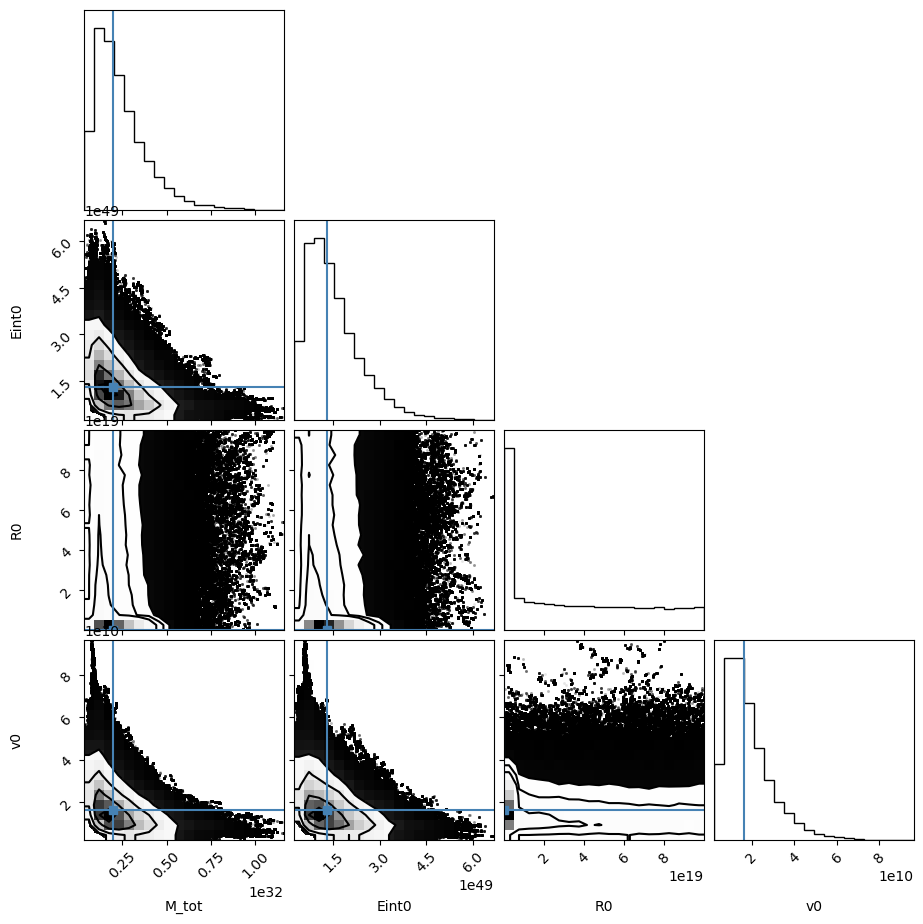

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import pickle
import emcee
import corner
from multiprocessing import Pool

# Constants
M_sun = 2e33
M_tot = 0.01 * M_sun
c = 3e10
v_min = 0.1 * c
beta = 3
numshells = 10
sigma = 5.67e-5
h = 6.626e-27
nu = 1e14
D = 1e26
kB = 1.38e-16

# Time array
t = np.logspace(0, 6, 50)

# Velocity array for each shell
v_shells = np.linspace(0.1, 1, numshells) * c

# Mass distribution
M_shells = beta * M_tot * (v_min**(beta)) * (v_shells**(-beta-1))
M_shells = M_shells * M_tot / np.sum(M_shells)
E_int_shells = 0.5 * M_shells * (v_shells**2)

# Shell dataframe
shell_data = pd.DataFrame({'Velocity (cm/s)': v_shells, 'Mass (g)': M_shells, 'Internal Energy (erg)': E_int_shells})

# Heating efficiency
av = 0.56
bv = 0.71
cv = 0.74
xr = 0.6
kv = [20, 5, 1]

def eps_th_v(t):
    t_day = t / 86400
    exp_term = np.exp(-av * t_day)
    log_term = np.log(1 + 2 * bv * t_day**cv)
    result = 0.36 * (exp_term + (log_term / (2 * bv * t_day**cv)))
    return result

def e_dot_r(t):
    t0 = 1.3
    sigma_val = 0.11
    arctan_term = np.arctan((t - t0) / sigma_val)
    result = 4e18 * eps_th_v(t) * (0.5 - (1 / np.pi) * arctan_term)**1.3
    return result

def Q_rv(Mv, t):
    return Mv * xr * e_dot_r(t)

def t_diff(M_shell, t):
    return ((M_shell**(4./3.)) * kv[2]) / (4 * np.pi * (M_tot**(1./3.)) * v_min * t * c)

def L_v(R, Eint, t_diff_val):
    t_lc = (R / c)
    return Eint / (t_diff_val + t_lc)

def energy(y, t, M):
    Eint, R, v = y
    diff_time = t_diff(M, t)
    dEint = -((Eint / R) * v) + Q_rv(M, t) - L_v(R, Eint, diff_time)
    dR = v
    dv = Eint / (M * R)
    return [dEint, dR, dv]

def pre_solve_shells(shell_data, t):
    E_all, R_all, v_all = [], [], []
    for i, row in shell_data.iterrows():
        M = row['Mass (g)']
        Eint0 = row['Internal Energy (erg)']
        v0 = row['Velocity (cm/s)']
        R0 = 1e9
        y0 = [Eint0, R0, v0]
        Edep = odeint(energy, y0, t, args=(M,))
        E_all.append(Edep[:, 0])
        R_all.append(Edep[:, 1])
        v_all.append(Edep[:, 2])
    return np.array(E_all), np.array(R_all), np.array(v_all)

def compute_photosphere_radius(R_all, shell_masses, t):
    num_shells, num_times = R_all.shape
    R_ph = np.zeros(num_times)
    tau_all = np.zeros_like(R_all)
    for i in range(num_shells):
        tau_all[i, :] = kv[2] * shell_masses[i] / (4 * np.pi * R_all[i, :]**2)
    tau_cumu = np.cumsum(tau_all[::-1], axis=0)[::-1]
    for i in range(num_times):
        tau_cumu_at_t = tau_cumu[:, i]
        if tau_cumu_at_t[-1] < 1:
            R_ph[i] = R_all[-1, i]
        else:
            idx = np.where(tau_cumu_at_t >= 1)[0][0]
            if idx == 0:
                R_ph[i] = R_all[0, i]
            else:
                tau_low = tau_cumu_at_t[idx - 1]
                tau_high = tau_cumu_at_t[idx]
                R_low = R_all[idx - 1, i]
                R_high = R_all[idx, i]
                f = (1 - tau_low) / (tau_high - tau_low)
                R_ph[i] = R_low + f * (R_high - R_low)
    return R_ph

def calculate_flux(R_ph, L_tot):
    T_eff = (L_tot / (4 * np.pi * sigma * R_ph**2))**(1/4)
    Flux = ((2 * np.pi * h * nu**3) / (c**2)) * (1 / (np.exp((h * nu) / (kB * T_eff)) - 1)) * (R_ph**2 / D**2)
    return Flux

# --- Precomputations ---
E_all, R_all, v_all = pre_solve_shells(shell_data, t)
R_ph_base = compute_photosphere_radius(R_all, M_shells, t)
L_tot_base = np.sum([L_v(R, Eint, t_diff(shell_data['Mass (g)'][i], t)) 
                     for i, (R, Eint) in enumerate(zip(R_all, E_all))], axis=0)
Flux_base = calculate_flux(R_ph_base, L_tot_base)

# --- Generate mock data ---
Flux_values = Flux_base.copy()
noise = 0.1 * Flux_values
Flux_perturbed = Flux_values + noise * np.random.randn(*Flux_values.shape)

# --- Fast Model ---
def model(theta, t, Flux_base):
    M_tot_prime, Eint0_prime, R0_prime, v0_prime = theta
    scaling = (M_tot_prime / M_tot) * (Eint0_prime / np.mean(E_int_shells)) * (v0_prime / np.mean(v_shells))
    Flux_model = scaling * Flux_base
    return Flux_model

def log_prior(theta):
    M_tot_prime, Eint0_prime, R0_prime, v0_prime = theta
    if (1e20 < M_tot_prime < 1e40 and
        1e30 < Eint0_prime < 1e60 and
        1e5 < R0_prime < 1e20 and
        1e7 < v0_prime < 1e12):
        return 0.0
    return -np.inf

def log_likelihood(theta, t, y, yerr, Flux_base):
    model_flux = model(theta, t, Flux_base)
    return -0.5 * np.sum(((y - model_flux) / yerr)**2)

def log_posterior(theta, t, y, yerr, Flux_base):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, y, yerr, Flux_base)

# --- Run MCMC without multiprocessing ---
def run_mcmc(initial, t, Flux_perturbed, noise, Flux_base, nsteps=10000, nwalkers=100, ndim=4):
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(t, Flux_perturbed, noise, Flux_base))
    sampler.run_mcmc(initial, nsteps, progress=True)
    return sampler

# --- Initial walker setup ---
Eint0 = np.mean(E_int_shells)
v0 = np.mean(v_shells)
R0 = 1e9

mass_noise_scale = 0.1
Eint0_noise_scale = 0.1
v0_noise_scale = 0.05
R0_noise_scale = 0.05

ndim = 4
nwalkers = 100
nsteps = 10000

initial = np.array([M_tot, Eint0, R0, v0]) + np.array([mass_noise_scale * M_tot, Eint0_noise_scale * Eint0,
                                                       R0_noise_scale * R0, v0_noise_scale * v0]) * np.random.randn(nwalkers, ndim)

# --- Run the sampler ---
sampler = run_mcmc(initial, t, Flux_perturbed, noise, Flux_base)

# Extract samples after burn-in (discard first 1000 steps)
samples = sampler.get_chain(discard=1000, thin=10, flat=True)
# --- Plot the results ---
samples = sampler.get_chain(flat=True)
corner.corner(samples, labels=["M_tot", "Eint0", "R0", "v0"], truths=[M_tot, Eint0, R0, v0])
plt.show()


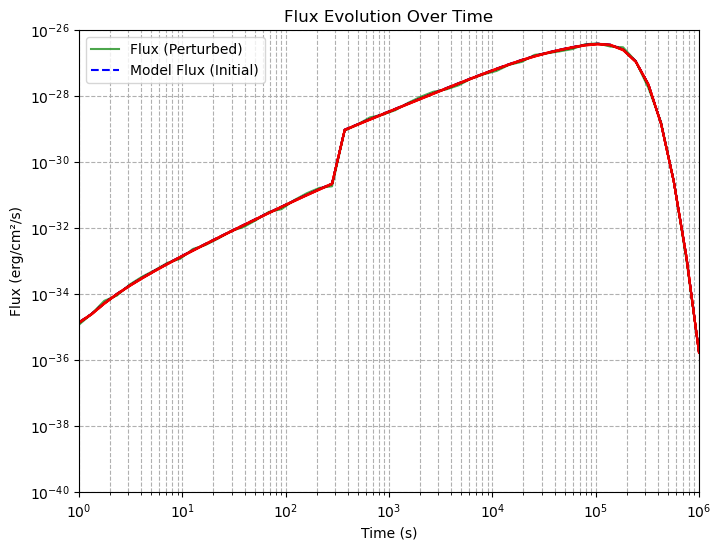

In [12]:

# Use the same initial parameters
Eint0 = np.mean(E_int_shells)
v0 = np.mean(v_shells)
R0 = 1e9
y0 = [M_tot, Eint0, R0, v0]

# Create the plot
plt.figure(figsize=(8, 6))

# Plot the perturbed flux (mock observational data)
plt.loglog(t, Flux_perturbed, label='Flux (Perturbed)', color='green', alpha=0.7)

# Plot the initial model flux
plt.loglog(t, model(y0, t, Flux_base), label='Model Flux (Initial)', color='blue', linestyle='--')

# Plot random MCMC sample models
for theta in samples[np.random.randint(len(samples), size=100)]:
    plt.plot(t, model(theta, t, Flux_base), color="red", alpha=0.05)

# Labels, limits, and grid
plt.xlabel('Time (s)')
plt.ylabel('Flux (erg/cm²/s)')
plt.xlim([1, 1e6])
plt.ylim([1e-40, 1e-26])
plt.title('Flux Evolution Over Time')

plt.grid(True, which="both", ls="--")
plt.legend()

# Show the plot
plt.show()


In [13]:
print("Mean acceptance fraction:", np.mean(sampler.acceptance_fraction))
try:
    tau = sampler.get_autocorr_time()
    print("Autocorrelation time:", tau)
except emcee.autocorr.AutocorrError:
    print("Chain too short to estimate autocorrelation time.")

Mean acceptance fraction: 0.1040064
Chain too short to estimate autocorrelation time.


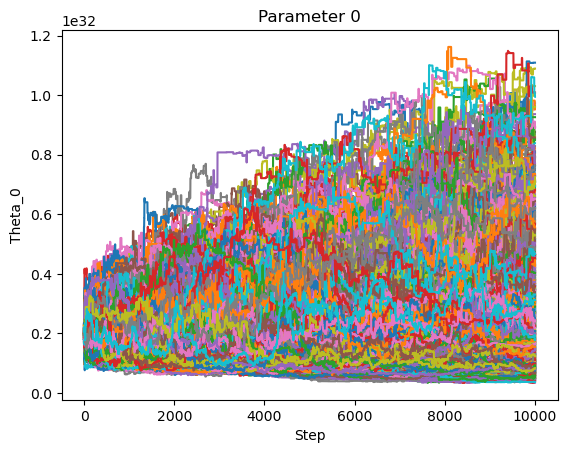

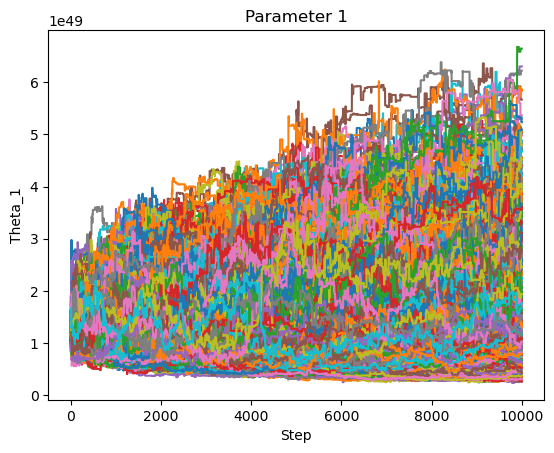

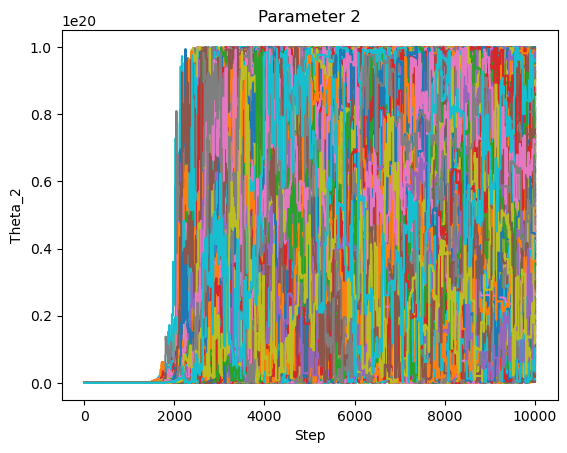

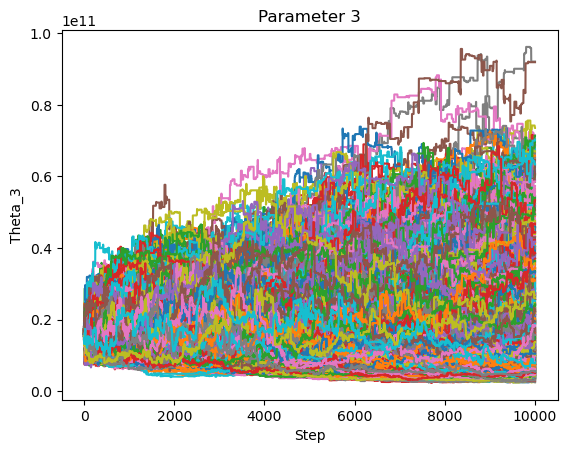

In [14]:
for i in range(ndim):
    plt.plot(sampler.get_chain()[:, :, i])
    plt.title(f"Parameter {i}")
    plt.xlabel("Step")
    plt.ylabel(f"Theta_{i}")
    plt.show()